<a href="https://colab.research.google.com/github/chandraniraychowdhury5/DS/blob/main/Wind_EnergyClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This project incorporates AI-assisted development to improve productivity.**
# **Feedback or Suggestions are welcome**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


Dataset Shape : (43791, 17)
                  Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 06:00:00            26.7                   92         24.9   
1  2017-01-02 07:00:00            28.4                   91         26.1   
2  2017-01-02 08:00:00            30.2                   88         27.0   
3  2017-01-02 09:00:00            34.0                   82         29.1   
4  2017-01-02 10:00:00            35.6                   73         27.7   

   windspeed_10m  winddirection_10m  windgusts_10m  Wind_Shear_Coefficient  \
0           2.10                 65            4.7                0.442704   
1           3.10                 69            4.8                0.303823   
2           3.54                 74            5.8                0.289216   
3           3.44                 82            6.5                0.242316   
4           3.71                 93            8.0                0.156538   

   Air_Density  Wind_Veering       U10       V

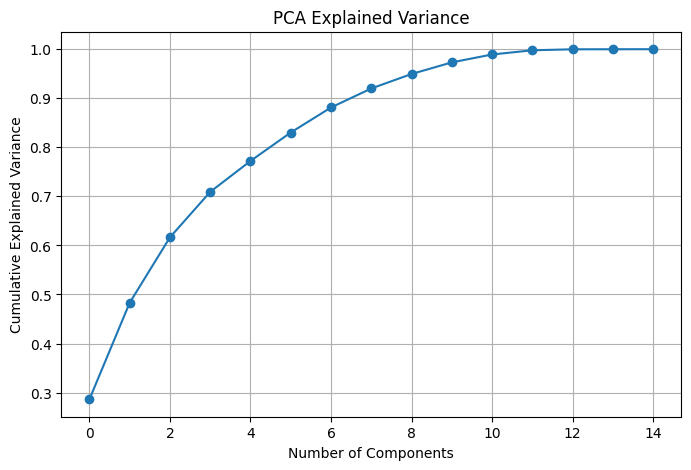


Variance Explained by First Two Components
[0.2864118  0.19676874]

Finding Optimal Number of Clusters...


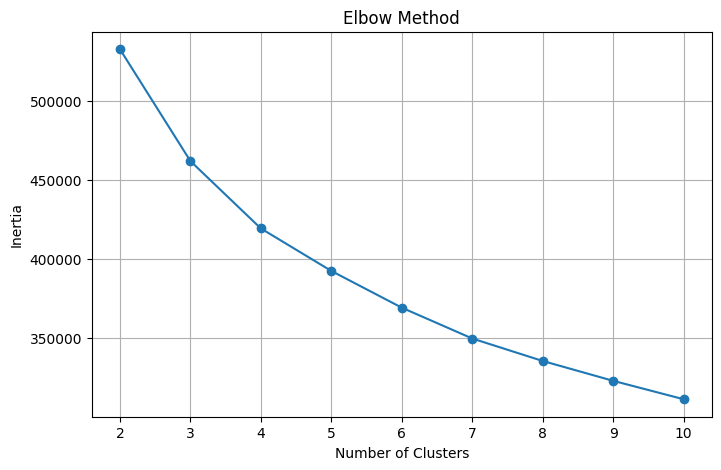


Cluster Counts
KMeans_Cluster
1    17777
0    15106
2    10908
Name: count, dtype: int64

KMeans Performance
----------------------------------------
Silhouette Score : 0.17134889708787698
Davies-Bouldin Index : 1.791450082590864
Calinski-Harabasz Score : 9242.046188069311


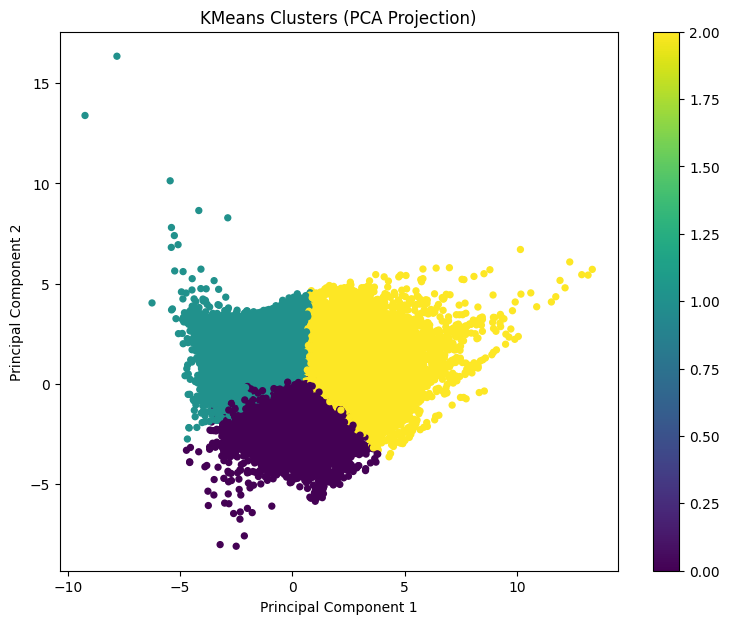


Cluster Profile
                temperature_2m  relativehumidity_2m  dewpoint_2m  \
KMeans_Cluster                                                     
0                    31.194618            76.943268    24.400874   
1                    65.286859            71.892783    55.042482   
2                    42.558086            66.480106    31.348753   

                windspeed_10m  winddirection_10m  windgusts_10m  \
KMeans_Cluster                                                    
0                    2.902674         208.770025       5.973401   
1                    2.835286         176.150925       6.509917   
2                    5.778351         241.385497      12.322607   

                Wind_Shear_Coefficient  Air_Density  Wind_Veering       U10  \
KMeans_Cluster                                                                
0                             0.273446     1.292646      7.711307 -0.673736   
1                             0.233992     1.203764      3.407774 -0.

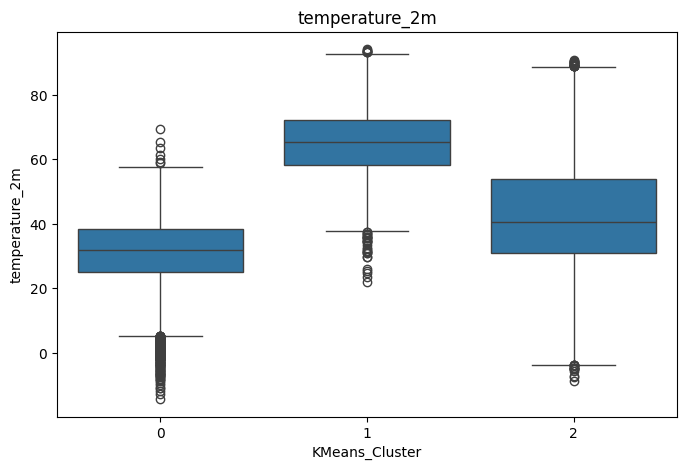

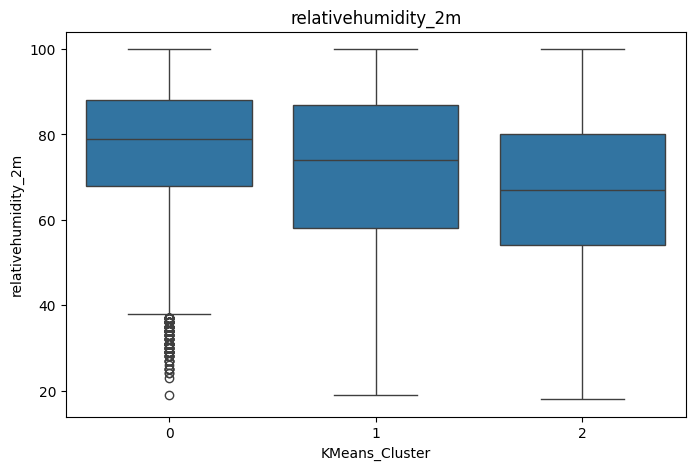

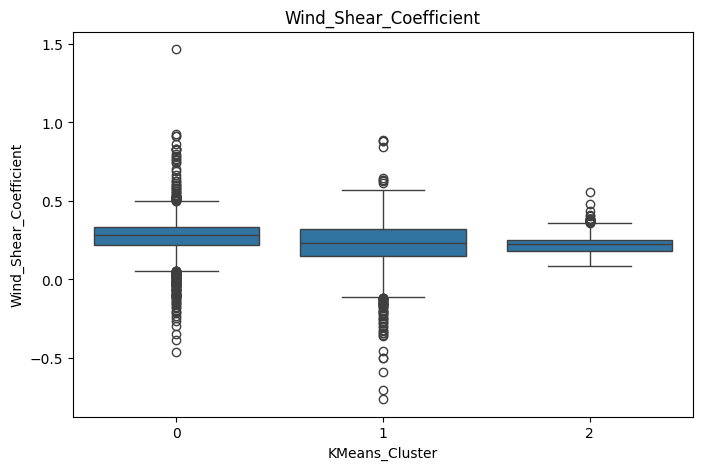

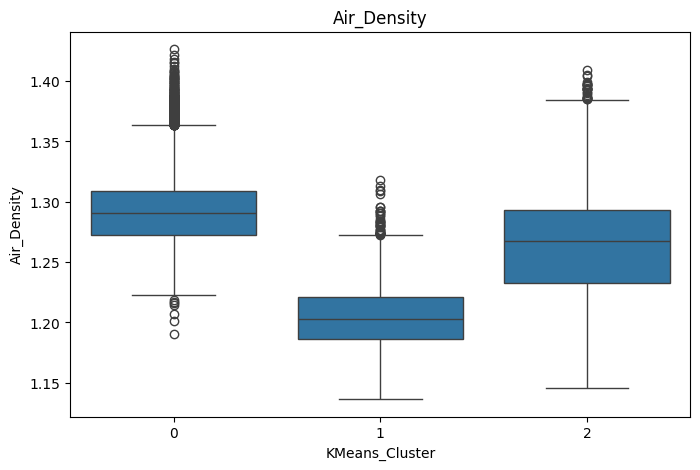

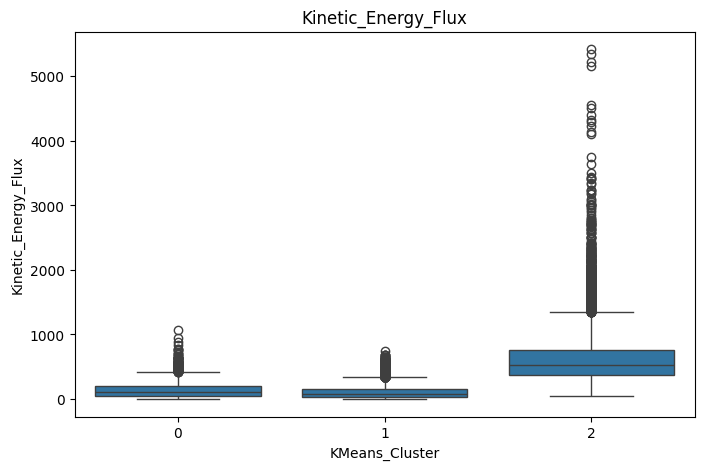


Results Saved Successfully
Figures Folder  : figures/
Results Folder  : results/


In [ ]:

# ==========================================================
# Create Result Folder
# ==========================================================

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("/content/drive/MyDrive/datasetAndProgram/WindDatasetForPrediction.csv")

print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

print(df.head())

# ==========================================================
# Data Cleaning
# ==========================================================

print("\nMissing Values")

print(df.isnull().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("\nShape After Cleaning")

print(df.shape)

# ==========================================================
# Remove Non-Numeric Columns
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

print("\nNumber of Numerical Features")

print(numeric_df.shape[1])

# ==========================================================
# Remove Target Variable
# ==========================================================

if "Power" in numeric_df.columns:
    X = numeric_df.drop(columns=["Power"])
else:
    X = numeric_df.copy()

print("\nFeature Matrix Shape")

print(X.shape)

# ==========================================================
# Standardization
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Dataset Shape")

print(X_scaled.shape)

# ==========================================================
# Principal Component Analysis
# ==========================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    explained,
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.savefig(
    "figures/PCA_ExplainedVariance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# PCA (2 Components)
# ==========================================================

pca2 = PCA(n_components=2)

X_2d = pca2.fit_transform(X_scaled)

print("\nVariance Explained by First Two Components")

print(pca2.explained_variance_ratio_)

# ==========================================================
# Elbow Method
# ==========================================================

print("\nFinding Optimal Number of Clusters...")

inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.savefig(
    "figures/Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# KMeans Clustering
# ==========================================================

optimal_clusters = 3

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

print("\nCluster Counts")

print(df["KMeans_Cluster"].value_counts())

# ==========================================================
# Evaluation Metrics
# ==========================================================

silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print("\nKMeans Performance")

print("-"*40)

print("Silhouette Score :", silhouette)

print("Davies-Bouldin Index :", davies)

print("Calinski-Harabasz Score :", calinski)

# ==========================================================
# PCA Cluster Visualization
# ==========================================================

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    cmap="viridis",
    s=18
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("KMeans Clusters (PCA Projection)")

plt.colorbar(scatter)

plt.savefig(
    "figures/KMeans_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# Cluster Profiling
# ==========================================================

cluster_profile = (
    df.groupby("KMeans_Cluster")
      .mean(numeric_only=True)
)

print("\nCluster Profile")

print(cluster_profile)

cluster_profile.to_csv(
    "results/KMeans_Cluster_Profile.csv"
)

# ==========================================================
# Feature Distribution by Cluster
# ==========================================================

important_features = [

    "windspeed_100m",

    "temperature_2m",

    "relativehumidity_2m",

    "Wind_Shear_Coefficient",

    "Air_Density",

    "Kinetic_Energy_Flux"

]

for feature in important_features:

    if feature in df.columns:

        plt.figure(figsize=(8,5))

        sns.boxplot(
            data=df,
            x="KMeans_Cluster",
            y=feature
        )

        plt.title(feature)

        plt.savefig(
            f"figures/{feature}_Cluster_Boxplot.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

# ==========================================================
# Save Dataset
# ==========================================================

df.to_csv(
    "results/KMeans_Clustered_Data.csv",
    index=False
)

print("\nResults Saved Successfully")

print("Figures Folder  : figures/")

print("Results Folder  : results/")

In [ ]:
import os
import shutil
from google.colab import drive


drive.mount('/content/drive')


drive_folder = "/content/drive/MyDrive/WindEnergy_Clustering"

os.makedirs(drive_folder, exist_ok=True)

# Copy folders to Google Drive
shutil.copytree("results",
                os.path.join(drive_folder, "results"),
                dirs_exist_ok=True)

shutil.copytree("figures",
                os.path.join(drive_folder, "figures"),
                dirs_exist_ok=True)

print("Results and figures copied to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results and figures copied to Google Drive.


In [ ]:
from google.colab import files

zip_name = "/content/drive/MyDrive/WindEnergy_Clustering"

shutil.make_archive(
    base_name=zip_name,
    format="zip",
    root_dir=drive_folder
)

files.download(zip_name + ".zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>